In [57]:
import sys
from pathlib import Path

def find_repo_root_local(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "tools").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPO_ROOT = find_repo_root_local(Path.cwd())
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas
import plotly.express as px
from entropy import hyper_edge_entropy, hyper_graph_entropy, hypergraph_shannon_entropy, persist_entropy
from experiment_utils import compute_coot_ot_gw_distances, convex_point, geodesic_distances, get_affinities, zscore

import topfmain

DORSOGNA_CSV = REPO_ROOT / "data" / "dorsogna" / "dorsogna.csv"

df = pandas.read_csv(DORSOGNA_CSV)
print(df.head())
df.columns = ['', 'time', 'x', 'y', 'vx', 'vy']

point_clouds_4d = {}
point_clouds_2d = {}
for t, group in df.groupby('time'):
    point_clouds_4d[t] = group[['x', 'y', 'vx', 'vy']].values
    point_clouds_2d[t] = group[['x', 'y']].values

timestamps = sorted(point_clouds_4d.keys())


数据预览:
   Unnamed: 0    t        x         y       vx       vy
0           1  0.0  0.18199 -0.095130 -0.60692 -0.79476
1           2  0.0 -0.36965  0.165070 -0.64805  0.76159
2           3  0.0  0.22099  0.431870 -0.65794  0.75307
3           4  0.0 -0.39138  0.309090  0.85197  0.52359
4           5  0.0 -0.38424 -0.017309 -0.18853  0.98207

时间 t=0.0 的点云形状 (4D): (500, 4)
每个时间步的粒子数量不一致，无法堆叠为规则的 3D 数组。


In [58]:
indices = np.linspace(297, len(timestamps) - 1, num=61, dtype=int)
t_index = [timestamps[i] for i in indices]
points_4d = []
points_2d = []

for t in t_index:
    X_t = point_clouds_4d[t]
    points_4d.append(X_t)
    X_t = point_clouds_2d[t]
    points_2d.append(X_t)


In [59]:
t_index


[1.0004,
 1.6716,
 2.343,
 3.0718,
 3.77,
 4.4822,
 5.1647,
 5.8254,
 6.5136,
 7.1722,
 7.9081,
 8.5937,
 9.3365,
 10.014,
 10.698,
 11.469,
 12.242,
 12.995,
 13.712,
 14.448,
 15.258,
 16.076,
 16.93,
 17.822,
 18.685,
 19.529,
 20.329,
 21.239,
 22.201,
 23.191,
 24.244,
 25.316,
 26.355,
 27.497,
 28.707,
 29.87,
 31.11,
 32.289,
 33.486,
 34.739,
 35.935,
 37.154,
 38.375,
 39.573,
 40.749,
 41.953,
 43.192,
 44.317,
 45.571,
 46.743,
 47.925,
 49.161,
 50.403,
 51.604,
 52.78,
 53.908,
 55.09,
 56.29,
 57.508,
 58.708,
 60.0]

In [60]:
import numpy as np
import plotly.express as px

frames_list = []

for i, points in enumerate(points_2d):
    pts_array = np.array(points)

    df = pandas.DataFrame({
        'x': pts_array[:, 0],
        'y': pts_array[:, 1],
        'frame': i
    })
    frames_list.append(df)

DF = pandas.concat(frames_list, ignore_index=True)

fig = px.scatter(
    DF,
    x="x",
    y="y",
    animation_frame="frame",
)

fig.update_traces(
    marker=dict(size=3, color='royalblue'), # 在这里统一设置大小和颜色
    selector=dict(mode='markers')
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 30
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 5

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_layout(
    width=600,
    height=500,
    showlegend=False # 纯点云可视化通常不需要图例
)

fig.show()


In [61]:
matching = np.array(np.where(ot.emd(w0, w1, pi_s.max()-pi_s) > 0)).T # round coupling

point_matching = []
pi_s_T = pi_s.T
for i in range(len(pi_s_T[:][-1])):
    sorted_indices = np.argsort(pi_s_T[i])
    point_matching.append([i, sorted_indices[-1]])

cycle_matching = []
pi_f_T = pi_f.T
for i in range(len(pi_f_T[:][-1])):
    sorted_indices = np.argsort(pi_f_T[i])
    cycle_matching.append([i, sorted_indices[-1]])

import numpy as np
from coot import dot, eta


In [63]:
import sys
sys.path.append("../../src/")
import numpy as np
import pandas
import importlib
import json
import ot
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import glob
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

import random
import tqdm
from tqdm import tqdm
import seaborn as sb
import scipy as sp
import topo_util
from topo_util import noisy_circle, noisy_ellipses
import sklearn as sk
import sklearn.decomposition
import math
import pd
import hypernetx as hnx
import tpot
import topfmain

A = points_4d[0]
B = points_4d[-1]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
A_normalized = scaler.fit_transform(A)
B_normalized = scaler.fit_transform(B)

C_v0, C_v1 = get_affinities(A), get_affinities(B)
p, q = ot.unif(len(A)), ot.unif(len(B))

topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,10], only_dims=[0,1]) for x in tqdm([A, B])]
y0 = topf_all[0][0]
y1 = topf_all[1][0]
df1, df2 = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
p_spt, q_spt = df1.iloc[:, :2].values, df2.iloc[:, :2].values

p, q = pd.augmented_weights(p_spt, q_spt)
C = pd.augmented_cost(p_spt, q_spt)
C_pd = pd.augmented_cost(p_spt, q_spt); #C_pd /= C_pd.mean()

C_v0, C_v1 = get_affinities(A), get_affinities(B)

alpha = 0.5
beta = 1

w0 = ot.unif(y0.shape[0])
w1 = ot.unif(y1.shape[0])
v0 = p
v1 = q
pi_s, pi_f, _, = tpot.TPOT(y0, y1, w0, w1, v0, v1,
                           C_v0, C_v1, C_pd,
                           beta = beta, alpha = alpha, print_iter = None, iter = 300,
                           solver = "sinkhorn",
                           eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

P = (pi_s / pi_s.sum(axis=-1)[:, np.newaxis])
Q = (pi_f[:-1, :-1] / pi_f[:-1, :-1].sum(axis=-1)[:, np.newaxis])
Q[np.isnan(Q)] = 0


100%|██████████| 2/2 [00:26<00:00, 13.42s/it]


is_converged, obj = 0.10422046066691484, obj_new = 0.10422046087741174


In [64]:
coot_values_gt = []
ot_values_gt = []
gw_values_gt = []
total_values_gt = []
pe_values_gt = []#persistent entropy
hge_values_gt = []#hyper graph entropy(new defined)
hse_values_gt = []#hypergraph shannon entropy
hee_values_gt = []#hyperedge entropy
geodesic_pd_gt = []#PD on the geodesic
sym_values_gt = []#symmetric hypergraph entropy

para_alpha = 0.5
for idx, X_t in enumerate(points_4d):
    print(f't={idx/len(points_4d)}')
    C_vt = get_affinities(X_t)
    topf_all = [topfmain.topf(x, return_dict = True, complex_type = 'rips', fixed_num_features = [0,10], only_dims=[0,1]) for x in tqdm([X_t])]
    yt = topf_all[0][0]
    dft = [pandas.DataFrame({"b" : x[1]['birth_times'], "d" : x[1]['death_times'], "pers" : np.array(x[1]['death_times']) - np.array(x[1]['birth_times'])}) for x in topf_all]
    g_spt = dft[0].iloc[:, :2].values

    p, g = pd.augmented_weights(p_spt, g_spt)
    C = pd.augmented_cost(p_spt, g_spt)
    C_pd = pd.augmented_cost(p_spt, g_spt); #C_pd /= C_pd.mean()

    alpha = 0.5
    beta = 1

    w0 = ot.unif(y0.shape[0])
    wt = ot.unif(yt.shape[0])
    v0 = p
    vt = g
    pi_s, pi_f, _, = tpot.TPOT(y0, yt, w0, wt, v0, vt,
                            C_v0, C_vt, C_pd,
                            beta = beta, alpha = alpha, print_iter = None, iter = 300,
                            solver = "sinkhorn",
                            eps_s = 0.003, eps_f = 0.01, numItermax = 2500)

    P = (pi_s / pi_s.sum(axis=-1)[:, np.newaxis])
    Q = (pi_f[:-1, :-1] / pi_f[:-1, :-1].sum(axis=-1)[:, np.newaxis])
    Q[np.isnan(Q)] = 0

    value = compute_coot_ot_gw_distances(y0, yt,
                           C_v0, C_vt, C_pd,
                           pi_s, pi_f,
                           alpha = alpha, beta=beta)
    coot_values_gt.append(value[0]/beta)
    ot_values_gt.append(value[1]/(1-alpha))
    gw_values_gt.append(value[2]/alpha)
    total_values_gt.append(value[2] + value[1] + value[0])

    pe_value = persist_entropy(g_spt)
    hge_value = hyper_graph_entropy(yt)
    hee_value = hyper_edge_entropy(yt)
    hse_value = hypergraph_shannon_entropy(yt)

    geodesic_pd_gt.append(g_spt)

    pe_values_gt.append(pe_value)
    hge_values_gt.append(hge_value)
    hee_values_gt.append(hee_value)
    hse_values_gt.append(hse_value)
    sym_values_gt.append(para_alpha * hge_value + (1-para_alpha) * hee_value)


t=0.0


100%|██████████| 1/1 [00:11<00:00, 11.53s/it]


is_converged, obj = 0.008807490532216463, obj_new = 0.008807489854122344
t=0.01639344262295082


100%|██████████| 1/1 [00:11<00:00, 11.85s/it]


is_converged, obj = 0.02605539598832102, obj_new = 0.026055395414175862
t=0.03278688524590164


...

t=0.9672131147540983


100%|██████████| 1/1 [00:14<00:00, 14.56s/it]


is_converged, obj = 0.11821617354970834, obj_new = 0.11821617255019377
t=0.9836065573770492


100%|██████████| 1/1 [00:16<00:00, 16.11s/it]


is_converged, obj = 0.10421851367591896, obj_new = 0.10421851387581595


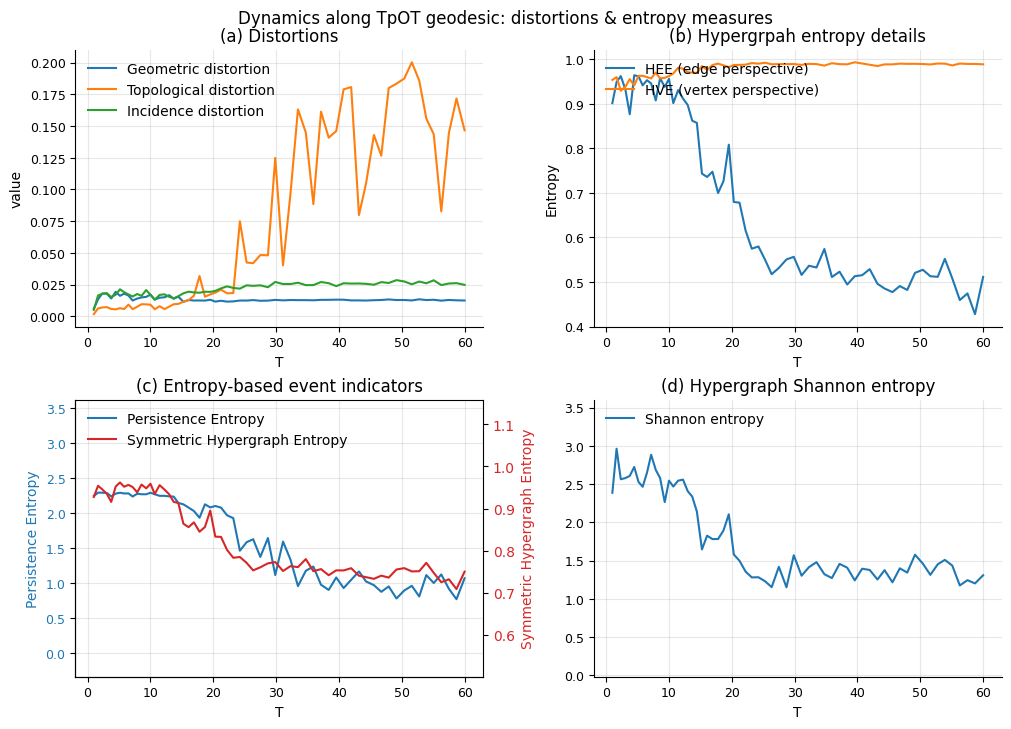

In [65]:
import numpy as np
import matplotlib.pyplot as plt
num_frames = len(pe_values_gt)

x = np.arange(len(pe_values_gt))

geom = np.asarray(gw_values_gt)        # 几何（你原来的 gw_values / geom Values）
topo = np.asarray(ot_values_gt)         # 拓扑
hyper = np.asarray(coot_values_gt)      # 超图/Incidence（你原来 coot 或类似）

PE = np.asarray(pe_values_gt)           # Persistence entropy
HE = np.asarray(hge_values_gt)          # Hypergraph entropy
HEE = np.asarray(hee_values_gt)         # Hyperedge-perspective entropy（或用 HEV）
SHE = np.asarray(sym_values_gt)         # Symmetric hypergraph entropy
HSE = np.asarray(hse_values_gt)

PE_z, HE_z, HEE_z, SHE_z = map(zscore, [PE, HE, HEE, SHE])
geom_z, topo_z, hyper_z = map(zscore, [geom, topo, hyper])

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, 0])  # (a)
axB = fig.add_subplot(gs[1, 0])  # (c)
axC = fig.add_subplot(gs[0, 1])  # (b)
axD = fig.add_subplot(gs[1, 1])  # (d)

axA.plot(t_index, geom, label='Geometric distortion')
axA.plot(t_index, topo, label='Topological distortion')
axA.plot(t_index, hyper, label='Incidence distortion')
axA.set_title('(a) Distortions')
axA.set_xlabel('T')
axA.set_ylabel('value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper left', ncol=1, frameon=False)

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(t_index, PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel('T')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(t_index, SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)
axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(c) Entropy-based event indicators')
lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(t_index, HEE, label='HEE (edge perspective)')
axC.plot(t_index, HE, label='HVE (vertex perspective)')
axC.set_title('(b) Hypergrpah entropy details')
axC.set_xlabel('T')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

axD.plot(t_index, HSE, label='Shannon entropy')
HSE_mean = np.nanmean(HSE)
HSE_range = np.nanmax(HSE)- np.nanmin(HSE)
axD.set_ylim(HSE_mean - 1*HSE_range, HSE_mean + 1*HSE_range)

axD.set_title('(d) Hypergraph Shannon entropy')
axD.set_xlabel('T')
axD.grid(True, alpha=0.3)
axD.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC, axD]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)
plt.show()


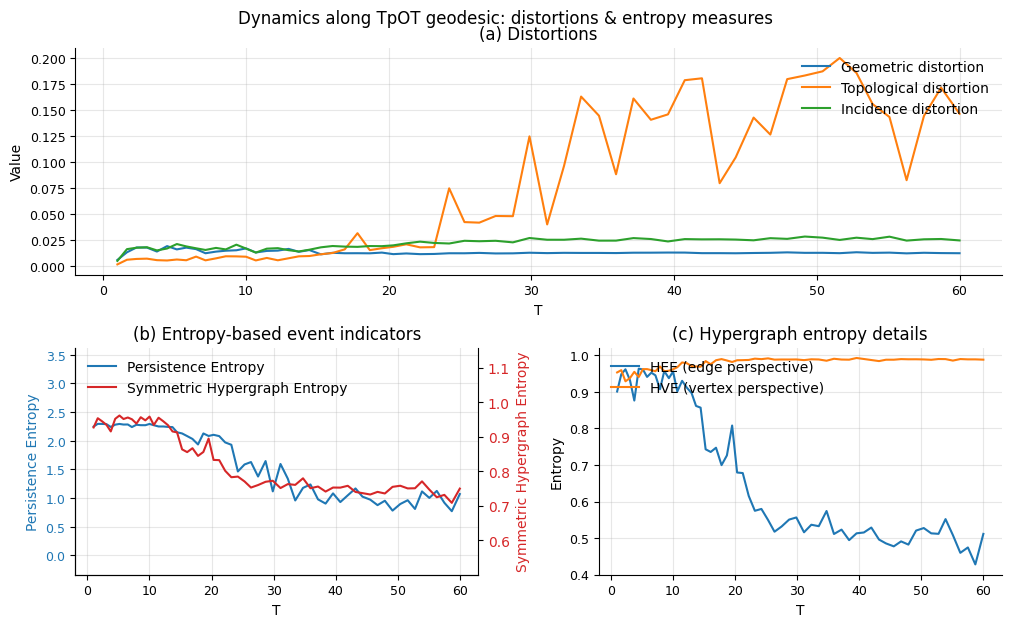

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6), constrained_layout=True)

gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, :])

axB = fig.add_subplot(gs[1, 0])

axC = fig.add_subplot(gs[1, 1])

axA.plot(t_index, geom, label='Geometric distortion')
axA.plot(t_index, topo, label='Topological distortion')
axA.plot(t_index, hyper, label='Incidence distortion')
axA.set_title('(a) Distortions')
axA.set_xlabel('T')
axA.set_ylabel('Value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper right', ncol=1, frameon=False) # 图变宽了，Legend 放右上可能更好

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(t_index, PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel('T')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(t_index, SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)

if pe_range == 0: pe_range = 1.0
if she_range == 0: she_range = 1.0

axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(b) Entropy-based event indicators') # 序号顺延改为 (b)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(t_index, HEE, label='HEE (edge perspective)')
axC.plot(t_index, HE, label='HVE (vertex perspective)')

axC.set_title('(c) Hypergraph entropy details') # 序号顺延改为 (c)
axC.set_xlabel('T')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axB:
        axB_r.spines['top'].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)

plt.show()


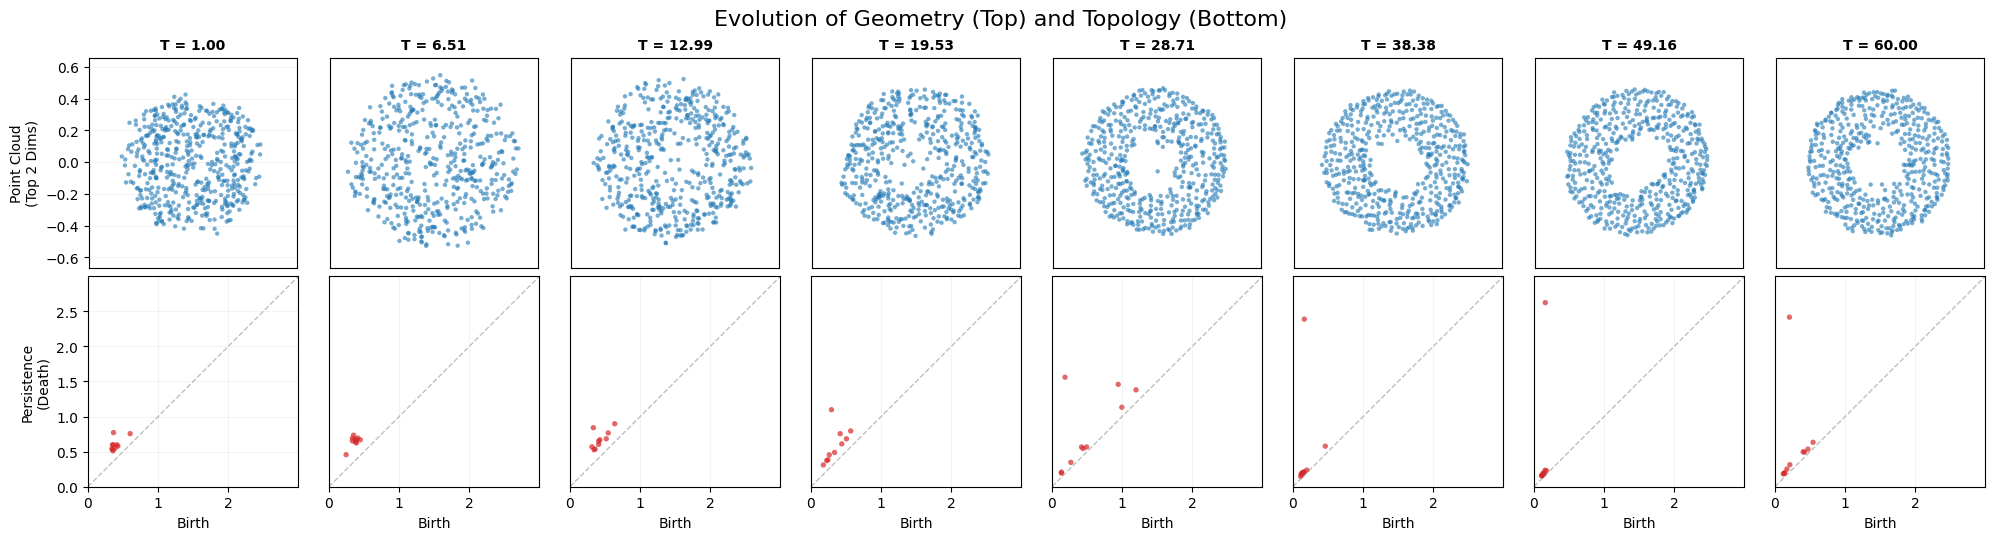

In [68]:
import numpy as np
import matplotlib.pyplot as plt

num_plots = 8  # 展示几列 (比如 8 个时间点)
total_frames = len(points_4d)

indices = np.linspace(0, total_frames - 1, num_plots, dtype=int)

all_points_concat = np.vstack(points_4d)
x_min, x_max = all_points_concat[:, 0].min(), all_points_concat[:, 0].max()
y_min, y_max = all_points_concat[:, 1].min(), all_points_concat[:, 1].max()

margin = 0.1
x_span = x_max - x_min
y_span = y_max - y_min
pc_xlim = (x_min - margin * x_span, x_max + margin * x_span)
pc_ylim = (y_min - margin * y_span, y_max + margin * y_span)

all_pd_concat = np.vstack([pd for pd in geodesic_pd_gt if len(pd) > 0])
pd_max = np.max(all_pd_concat) * 1.1 if len(all_pd_concat) > 0 else 1.0
pd_lim = (0, pd_max)

fig, axes = plt.subplots(2, num_plots, figsize=(20, 5), constrained_layout=True)

for plot_idx, frame_idx in enumerate(indices):
    cloud = points_4d[frame_idx]      # 形状 (N, 4)
    pd = geodesic_pd_gt[frame_idx]    # 形状 (M, 2)
    t_val = t_index[frame_idx]

    ax_pc = axes[0, plot_idx]
    ax_pc.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.6, c='tab:blue', edgecolors='none')

    ax_pc.set_title(f"T = {t_val:.2f}", fontsize=10, fontweight='bold')
    ax_pc.set_xlim(pc_xlim)
    ax_pc.set_ylim(pc_ylim)
    ax_pc.set_aspect('equal')
    ax_pc.grid(True, alpha=0.15)

    ax_pd = axes[1, plot_idx]

    ax_pd.plot(pd_lim, pd_lim, c='gray', linestyle='--', linewidth=1, alpha=0.5)

    if len(pd) > 0:
        ax_pd.scatter(pd[:, 0], pd[:, 1], s=15, alpha=0.7, c='tab:red', edgecolors='none')

    ax_pd.set_xlim(pd_lim)
    ax_pd.set_ylim(pd_lim)
    ax_pd.set_aspect('equal')
    ax_pd.grid(True, alpha=0.15)

    if plot_idx == 0:
        ax_pc.set_ylabel("Point Cloud\n(Top 2 Dims)")
        ax_pd.set_ylabel("Persistence\n(Death)")
    else:
        ax_pc.set_yticks([])
        ax_pd.set_yticks([])

    ax_pc.set_xticks([])
    ax_pd.set_xlabel("Birth")

plt.suptitle("Evolution of Geometry (Top) and Topology (Bottom)", fontsize=16, y=1.05)
plt.show()
